In [8]:
import numpy as np
import os
import sys
import tkinter as tk
import tifffile
import src.utils.ingaas_processing as ip
#import src.stitching.helpers as test
from src import stitching
from src.stitching import helpers
import cv2
from matplotlib import pyplot as plt
from tkinter import filedialog
import scipy
import io

root = tk.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

width, height = 640, 512
def undistortSingle(image,K,D,dim=(640,512),debug=False,parallel=True):
    """
    Undistorts a single image using the provided camera matrix and distortion coefficients.
    Parameters:
    image (numpy array): The distorted input images.
    K (numpy array): Camera matrix (intrinsic parameters).
    D (numpy array): Distortion coefficients.
    dim (tuple): The dimensions (width, height) of the image used in calibration. Default is (640, 512).
    Returns:
    undistorted_imgs (numpy array): The undistorted image.
    Raises:
    AssertionError: If the aspect ratio of the input image does not match the aspect ratio of the calibration dimensions.
    """

    #TODO:Maybe improve this to be parallel

    if not debug:
        dim1 = image.shape[:2][::-1]
        assert dim1[0] / dim1[1] == dim[0] / dim[1], "Image to undistort needs to have same aspect ratio as the ones used in calibration"

    #print(imageArr.shape)
    map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), K, dim, cv2.CV_16SC2)
    
    return cv2.remap(image, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)


In [15]:
im_path = filedialog.askopenfilename(title='Select image to process')
cal_path = "data/calibration.npz"
K,P,DIM = ip.load_calibration(cal_path)
images = tifffile.imread(im_path)
images_undistort = np.array(undistortSingle(images, K, P, DIM))

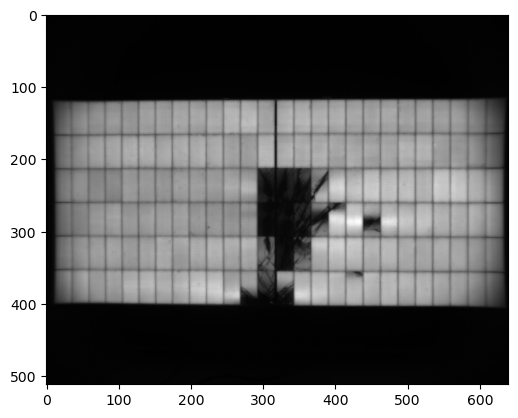

Saved to: C:/Users/carle/Desktop/snapshot_10092026_142641_undistorted.png


In [ ]:
plt.imshow(images_undistort, cmap='gray')
plt.show()

output_path = os.path.splitext(im_path)[0] + "_undistorted.png"
# PNG supports unsigned integer grayscale data
image_png = cv2.normalize(
    images_undistort, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)
cv2.imwrite(output_path, image_png)

print(f"Saved to: {output_path}")
